In [3]:
from click.core import batch
!nvidia-smi

Sun Oct  5 08:41:56 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.94                 Driver Version: 560.94         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A2000 8GB Lap...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   55C    P8              4W /   45W |     337MiB /   8192MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import torch
print("Cuda available:", torch.cuda.is_available())
print("Name:", torch.cuda.get_device_name(0))
print("Cuda device count:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device())
print("Device:", torch.cuda.get_device_properties(0))

Cuda available: True
Name: NVIDIA RTX A2000 8GB Laptop GPU
Cuda device count: 1
Current device: 0
Device: _CudaDeviceProperties(name='NVIDIA RTX A2000 8GB Laptop GPU', major=8, minor=6, total_memory=8191MB, multi_processor_count=20, uuid=f443c088-55ca-9670-a139-6060031e3577, L2_cache_size=2MB)


In [5]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.59  Python-3.10.16 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX A2000 8GB Laptop GPU, 8192MiB)
Setup complete  (20 CPUs, 31.7 GB RAM, 69.0/250.0 GB disk)


In [6]:
from roboflow import Roboflow
rf = Roboflow(api_key="v0SQsU9ebAuce09D3kTD")
project = rf.workspace("blindsupport").project("bas-thesis-dataset-oiupy")
version = project.version(3)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to BAS---Thesis-Dataset-3 in yolov11:: 100%|██████████| 24800/24800 [00:06<00:00, 4035.53it/s]


In [7]:
from ultralytics import YOLO

#------------------------
# Load a model
#------------------------
model = YOLO("yolo11m.pt")

#------------------------
# Training parameters
#------------------------
train_results = model.train(
    data='T:\\2. Graduation Thesis\\OD\\BAS---Thesis-Dataset-3\\data.yaml',
    epochs=200,
    imgsz=640,
    workers=2,
    device=0,
    optimizer='AdamW',
    lr0=3e-4,  # initial learning rate
    lrf=0.01,  # final learning rate = lr0 * lrf
    weight_decay=0.0005,
    amp=True,  # Automatic Mixed Precision
    batch=8,

    # Augmentations
    patience=20,          # Early stop patience (stop if no val improvement in 20 epochs)
    cos_lr=True,          # Cosine LR schedule (better than step decay here)
    mosaic=0.5,           # Keep mosaic on for augmentation
    hsv_h=0.015,          # Hue jitter
    hsv_s=0.1,            # Saturation jitter
    hsv_v=0.1,            # Value jitter
    flipud=0.0,           # Avoid vertical flip (not realistic for metro scenes)
    fliplr=0.5,           # Allow horizontal flip
    mixup=0.1,            # Mild mixup helps regularization
    copy_paste=0.1,       # Copy-paste augmentation for rare classes
)

New https://pypi.org/project/ultralytics/8.3.204 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.59  Python-3.10.16 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX A2000 8GB Laptop GPU, 8192MiB)
engine\trainer: task=detect, mode=train, model=yolo11m.pt, data=T:\2. Graduation Thesis\OD\BAS---Thesis-Dataset-3\data.yaml, epochs=200, time=None, patience=20, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=2, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retin

train: Scanning T:\2. Graduation Thesis\OD\BAS---Thesis-Dataset-3\train\labels... 11216 images, 222 backgrounds, 0 corrupt: 100%|██████████| 11216/11216 [00:04<00:00, 2592.43it/s]


train: New cache created: T:\2. Graduation Thesis\OD\BAS---Thesis-Dataset-3\train\labels.cache
WARNING  Box and segment counts should be equal, but got len(segments) = 1674, len(boxes) = 15587. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


val: Scanning T:\2. Graduation Thesis\OD\BAS---Thesis-Dataset-3\valid\labels... 958 images, 7 backgrounds, 0 corrupt: 100%|██████████| 958/958 [00:00<00:00, 2429.84it/s]


val: New cache created: T:\2. Graduation Thesis\OD\BAS---Thesis-Dataset-3\valid\labels.cache
WARNING  Box and segment counts should be equal, but got len(segments) = 181, len(boxes) = 1301. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
Plotting labels to runs\detect\train2\labels.jpg... 
optimizer: AdamW(lr=0.0003, momentum=0.937) with parameter groups 106 weight(decay=0.0), 113 weight(decay=0.0005), 112 bias(decay=0.0)


...

     76/200      4.64G     0.6604     0.4099      1.087         20        640: 100%|██████████| 1402/1402 [08:29<00:00,  2.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 60/60 [00:17<00:00,  3.37it/s]

                   all        958       1301      0.957      0.952      0.967       0.78
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 56, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



76 epochs completed in 11.579 hours.
Optimizer stripped from runs\detect\train2\weights\last.pt, 40.5MB
Optimizer stripped from runs\detect\train2\weights\best.pt, 40.5MB

Validating runs\detect\train2\weights\best.pt...
Ultralytics 8.3.59  Python-3.10.16 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX A2000 8GB Laptop GPU, 8192MiB)
YOLO11m summary (fused): 303 layers, 20,040,826 parameters, 0 gradients, 67.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 60/60 [00:17<00:00,  3.37it/s]


                   all        958       1301      0.955      0.954       0.97      0.782
           closed gate         20         20       0.98          1      0.995      0.952
           crossingpos         50         58      0.949      0.963      0.975       0.74
             downstair         33         33      0.919      0.939      0.953      0.861
              elevator         28         29      0.984          1      0.995      0.813
  escalator entry node         19         19      0.981          1      0.995      0.885
            greenlight        260        270      0.953      0.895      0.943      0.516
             open gate          8          8      0.954          1      0.995      0.918
           pillar node         24         37      0.984      0.973      0.991      0.841
              redlight        181        183      0.922      0.836      0.915       0.62
            stair node         40         40       0.99          1      0.995      0.845
                  sto

## Inference


In [8]:
from ultralytics import YOLO

model = YOLO("T:\\2. Graduation Thesis\\OD\\runs\\detect\\train2\\weights\\best.pt")


0: 640x640 2 redlights, 1 trafficlight, 21.3ms
1: 640x640 1 stop, 21.3ms
2: 640x640 1 escalator entry node, 21.3ms
3: 640x640 1 closed gate, 21.3ms
4: 640x640 1 open gate, 21.3ms
5: 640x640 2 ticket booths, 21.3ms
6: 640x640 1 stair node, 21.3ms
7: 640x640 2 escalator entry nodes, 1 stair node, 21.3ms
8: 640x640 1 escalator entry node, 21.3ms
9: 640x640 1 elevator, 1 pillar node, 1 stair node, 21.3ms
10: 640x640 2 pillar nodes, 21.3ms
Speed: 2.9ms preprocess, 21.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


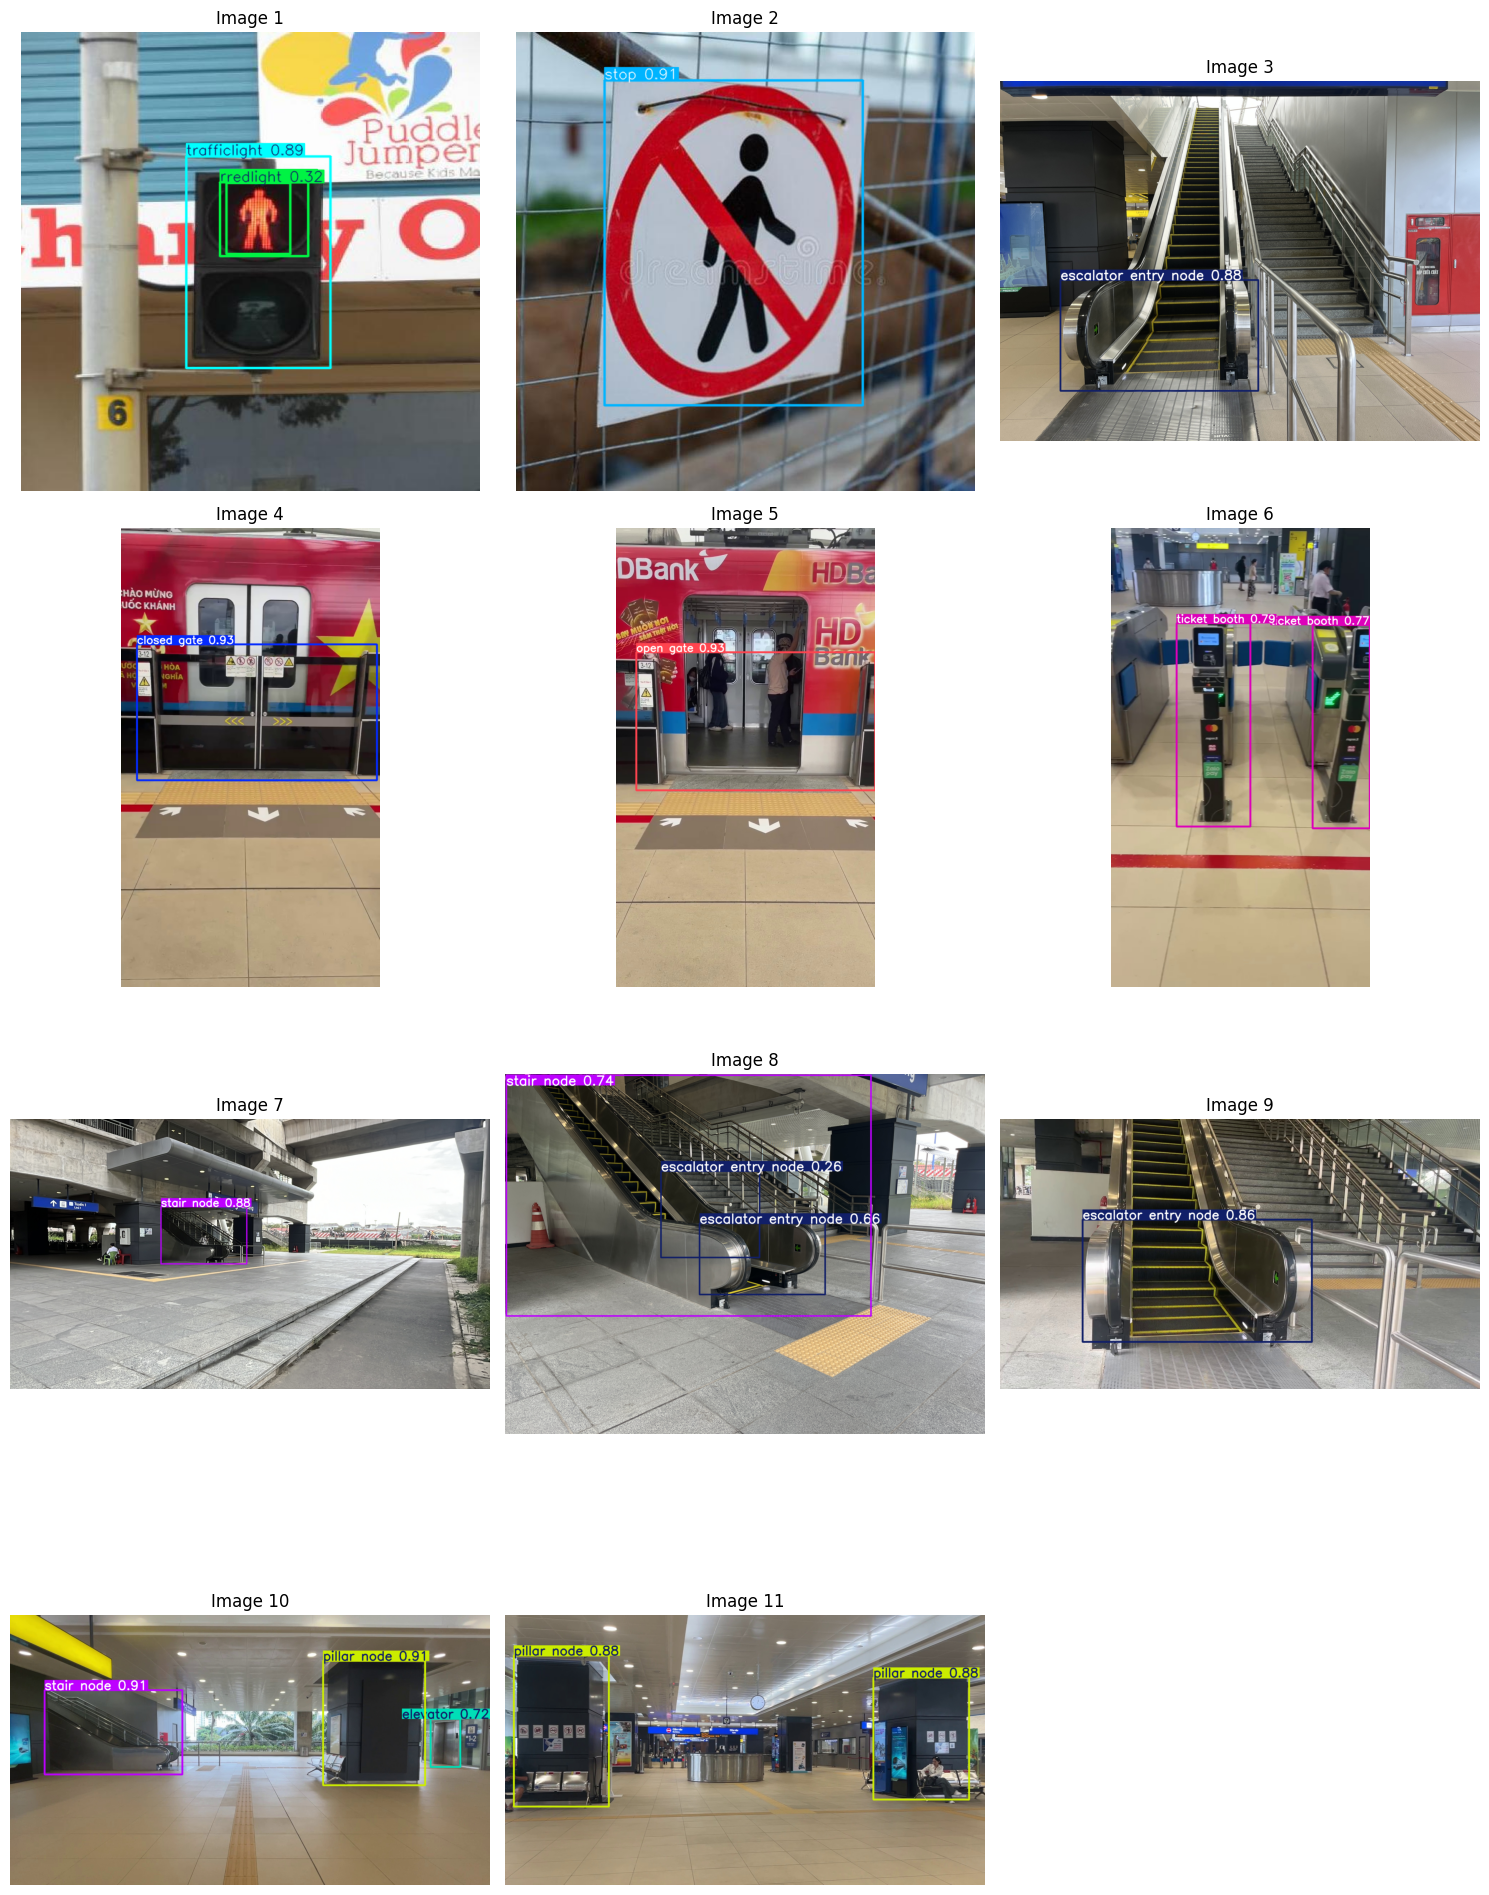

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2

image_paths = [
    r"T:\2. Graduation Thesis\OD\BAS---Thesis-Dataset-3\test\images\035_jpg.rf.608ab84de49be2f18846098b1cf5e8e3.jpg",
    r"T:\2. Graduation Thesis\OD\BAS---Thesis-Dataset-3\test\images\1337_jpg.rf.d81fdc55c3933544b1d84557743bde5c.jpg",
    r"T:\2. Graduation Thesis\OD\test3.jpg",
    r"T:\2. Graduation Thesis\raw_data\OD\1J6CHCKFP_8AE3KG_frame_000066.jpg",
    r"T:\2. Graduation Thesis\raw_data\OD\1J6CHCKFP_8AE3KG_frame_001013.jpg",
    r"T:\2. Graduation Thesis\raw_data\OD\1J6CHG2UP_8AE3KG_frame_000207.jpg",
    r"T:\2. Graduation Thesis\raw_data\OD\IMG_1973.JPG",
    r"T:\2. Graduation Thesis\raw_data\OD\IMG_1975.JPG",
    r"T:\2. Graduation Thesis\raw_data\OD\IMG_2823_frame_002258.jpg",
    r"T:\2. Graduation Thesis\raw_data\OD\IMG_2827_frame_003645.jpg",
    r"T:\2. Graduation Thesis\raw_data\OD\IMG_2825_frame_000203.jpg"
]

results = model(image_paths)

# Plot results nicely in a grid
n_images = len(results)
cols = 3  # adjust grid columns
rows = (n_images + cols - 1) // cols  # auto calculate rows

plt.figure(figsize=(15, 5 * rows))

for i, result in enumerate(results):
    annotated = result.plot()
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(annotated_rgb)
    plt.axis("off")
    plt.title(f"Image {i+1}")

plt.tight_layout()
plt.show()


## Deploy Model

In [11]:
from ultralytics import YOLO

# Load your trained model
model = YOLO("T:\\2. Graduation Thesis\\OD\\runs\\detect\\train2\\weights\\best.pt")

# Export to ONNX
model.export(format="onnx", opset=12)

Ultralytics 8.3.59  Python-3.10.16 torch-2.5.1+cu121 CPU (12th Gen Intel Core(TM) i7-12800H)
YOLO11m summary (fused): 303 layers, 20,040,826 parameters, 0 gradients, 67.7 GFLOPs

PyTorch: starting from 'T:\2. Graduation Thesis\OD\runs\detect\train2\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 18, 8400) (38.7 MB)

ONNX: starting export with onnx 1.19.0 opset 12...
ONNX: slimming with onnxslim 0.1.70...
ONNX: export success  2.4s, saved as 'T:\2. Graduation Thesis\OD\runs\detect\train2\weights\best.onnx' (76.7 MB)

Export complete (3.6s)
Results saved to T:\2. Graduation Thesis\OD\runs\detect\train2\weights
Predict:         yolo predict task=detect model=T:\2. Graduation Thesis\OD\runs\detect\train2\weights\best.onnx imgsz=640  
Validate:        yolo val task=detect model=T:\2. Graduation Thesis\OD\runs\detect\train2\weights\best.onnx imgsz=640 data=T:\2. Graduation Thesis\OD\BAS---Thesis-Dataset-3\data.yaml  
Visualize:       https://netron.app


'T:\\2. Graduation Thesis\\OD\\runs\\detect\\train2\\weights\\best.onnx'

In [12]:
# Export to TensorRT (FP16 for speed + VRAM savings)
from ultralytics import YOLO

# Load model again
model = YOLO("T:\\2. Graduation Thesis\\OD\\runs\\detect\\train2\\weights\\best.pt")

# Export to TensorRT FP16
model.export(format="engine", device=0, half=True)


Ultralytics 8.3.59  Python-3.10.16 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX A2000 8GB Laptop GPU, 8192MiB)
YOLO11m summary (fused): 303 layers, 20,040,826 parameters, 0 gradients, 67.7 GFLOPs

PyTorch: starting from 'T:\2. Graduation Thesis\OD\runs\detect\train2\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 18, 8400) (38.7 MB)

ONNX: starting export with onnx 1.19.0 opset 19...
ONNX: slimming with onnxslim 0.1.70...
ONNX: export success  2.7s, saved as 'T:\2. Graduation Thesis\OD\runs\detect\train2\weights\best.onnx' (76.7 MB)

TensorRT: starting export with TensorRT 10.13.3.9...
TensorRT: input "images" with shape(1, 3, 640, 640) DataType.FLOAT
TensorRT: output "output0" with shape(1, 18, 8400) DataType.FLOAT
TensorRT: building FP16 engine as T:\2. Graduation Thesis\OD\runs\detect\train2\weights\best.engine
TensorRT: export success  313.2s, saved as 'T:\2. Graduation Thesis\OD\runs\detect\train2\weights\best.engine' (43.4 MB)

Export complete (314.7s)
Res

'T:\\2. Graduation Thesis\\OD\\runs\\detect\\train2\\weights\\best.engine'